
Tidal datums from 1-year time series (units = same as WL column):
          Value
Datum          
HAT    3.994000
MHHW   2.710241
MHW    2.434113
DTL    1.212729
MTL    1.289082
MSL    1.280454
MLW    0.144051
MLLW  -0.284784
LAT   -1.325000
GT     2.995025


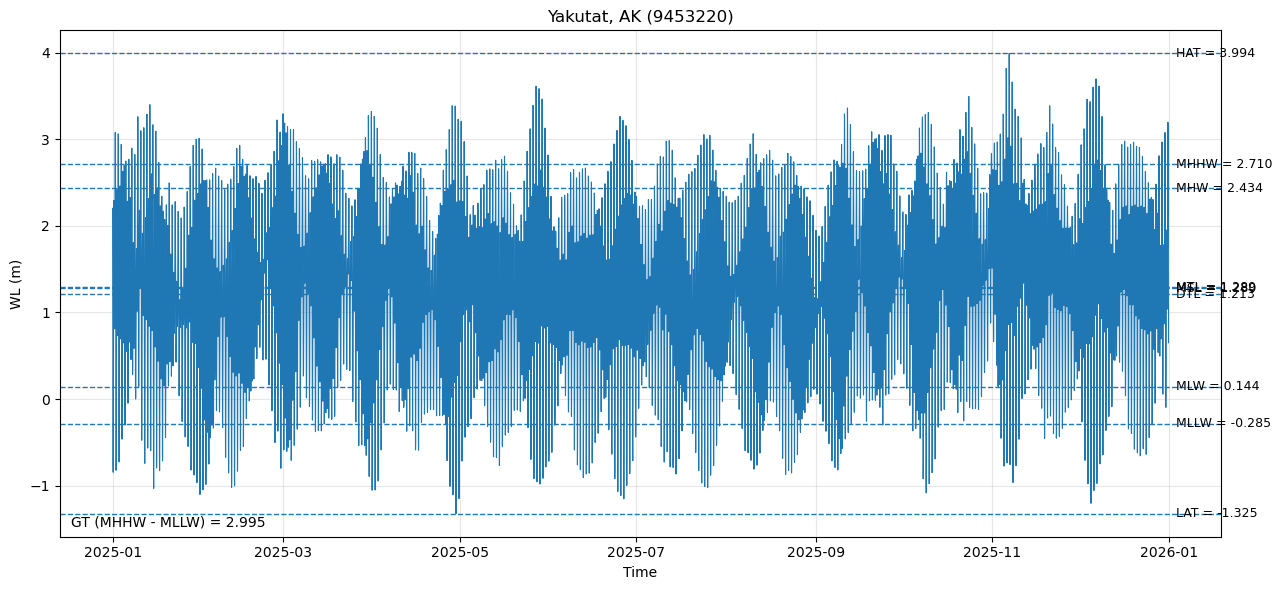

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9453220_met.csv"
time_col = "Time"
wl_col   = "WL"
# -------------------------------------------

def load_data(path, time_col, wl_col):
    df = pd.read_csv(path)
    if time_col not in df.columns or wl_col not in df.columns:
        raise ValueError(f"CSV must contain columns '{time_col}' and '{wl_col}'. Found: {list(df.columns)}")

    df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
    df[wl_col] = pd.to_numeric(df[wl_col], errors="coerce")
    df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col).reset_index(drop=True)
    return df

def find_local_extrema(df, time_col, wl_col):
    """
    Simple local extrema detector:
    - maxima where x[i] > x[i-1] and x[i] > x[i+1]
    - minima where x[i] < x[i-1] and x[i] < x[i+1]
    """
    x = df[wl_col].to_numpy()
    t = df[time_col].to_numpy()

    # Need at least 3 points
    if len(x) < 3:
        raise ValueError("Not enough data points to detect extrema.")

    maxima_mask = (x[1:-1] > x[:-2]) & (x[1:-1] > x[2:])
    minima_mask = (x[1:-1] < x[:-2]) & (x[1:-1] < x[2:])

    max_idx = np.where(maxima_mask)[0] + 1
    min_idx = np.where(minima_mask)[0] + 1

    highs = pd.DataFrame({time_col: t[max_idx], wl_col: x[max_idx]})
    lows  = pd.DataFrame({time_col: t[min_idx], wl_col: x[min_idx]})

    # Convert time back to datetime64[ns] for convenience
    highs[time_col] = pd.to_datetime(highs[time_col])
    lows[time_col]  = pd.to_datetime(lows[time_col])

    return highs, lows

def compute_datums(df, highs, lows, time_col, wl_col):
    df = df.copy()
    df["date"] = df[time_col].dt.date

    # MSL: mean of all water level samples (time-weighted if interval uniform)
    MSL = df[wl_col].mean()

    # HAT/LAT (approx from record)
    HAT = df[wl_col].max()
    LAT = df[wl_col].min()

    # Group extrema by day
    highs = highs.copy()
    lows  = lows.copy()
    highs["date"] = highs[time_col].dt.date
    lows["date"]  = lows[time_col].dt.date

    # For each day:
    # - identify higher high water (HHW): max of that day's highs
    # - identify lower low water (LLW): min of that day's lows
    daily_HHW = highs.groupby("date")[wl_col].max()     # higher high each day
    daily_LLW = lows.groupby("date")[wl_col].min()      # lower low each day

    # Mean Higher High Water (MHHW) and Mean Lower Low Water (MLLW)
    MHHW = daily_HHW.mean()
    MLLW = daily_LLW.mean()

    # Mean High Water (MHW): mean of *all* detected high waters
    # Mean Low Water (MLW): mean of *all* detected low waters
    MHW = highs[wl_col].mean()
    MLW = lows[wl_col].mean()

    # Mean Tide Level (MTL) and Diurnal Tide Level (DTL)
    MTL = 0.5 * (MHW + MLW)
    DTL = 0.5 * (MHHW + MLLW)

    # Great Diurnal Range (GT) – commonly taken as MHHW - MLLW
    GT = MHHW - MLLW

    datums = {
        "HAT":  HAT,
        "MHHW": MHHW,
        "MHW":  MHW,
        "DTL":  DTL,
        "MTL":  MTL,
        "MSL":  MSL,
        "MLW":  MLW,
        "MLLW": MLLW,
        "LAT":  LAT,
        "GT":   GT
    }
    return datums

def plot_wl_with_datums(df, datums, time_col, wl_col):
    fig, ax = plt.subplots(figsize=(13, 6))
    ax.plot(df[time_col], df[wl_col], linewidth=0.8)

    # Draw datum lines
    # (No custom colors specified—matplotlib will cycle defaults)
    y_min, y_max = df[wl_col].min(), df[wl_col].max()
    y_span = max(y_max - y_min, 1e-9)

    # Order to label nicely
    order = ["HAT", "MHHW", "MHW", "DTL", "MTL", "MSL", "MLW", "MLLW", "LAT"]
    for name in order:
        y = datums[name]
        ax.axhline(y, linestyle="--", linewidth=1.0)
        # Put label near right side
        ax.text(df[time_col].iloc[-1], y, f"  {name} = {y:.3f}",
                va="center", ha="left", fontsize=9)

    ax.set_title("Yakutat, AK (9453220)")
    ax.set_xlabel("Time")
    ax.set_ylabel("WL (m)")
    ax.grid(True, alpha=0.3)

    # Add GT as annotation (since it's not a level line)
    ax.text(0.01, 0.02, f"GT (MHHW - MLLW) = {datums['GT']:.3f}",
            transform=ax.transAxes, fontsize=10)

    plt.tight_layout()
    plt.show()

def print_datum_table(datums):
    tab = (pd.DataFrame({"Datum": list(datums.keys()),
                         "Value": list(datums.values())})
           .set_index("Datum")
           .loc[["HAT","MHHW","MHW","DTL","MTL","MSL","MLW","MLLW","LAT","GT"]])
    print("\nTidal datums from 1-year time series (units = same as WL column):")
    print(tab.to_string(float_format=lambda v: f"{v:0.6f}"))

def main():
    df = load_data(csv_path, time_col, wl_col)

    highs, lows = find_local_extrema(df, time_col, wl_col)

    # If the extrema detection is too “noisy” (many tiny peaks),
    # you can smooth WL first (rolling mean) before extrema detection.
    datums = compute_datums(df, highs, lows, time_col, wl_col)

    print_datum_table(datums)
    plot_wl_with_datums(df, datums, time_col, wl_col)

if __name__ == "__main__":
    main()


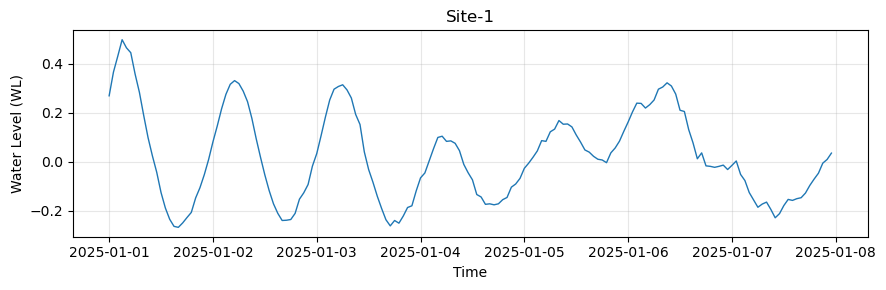

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8735180_met.csv"
time_col = "Time"
wl_col   = "WL"
# -------------------------------------------

# Read CSV
df = pd.read_csv(csv_path)

# Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col] = pd.to_numeric(df[wl_col], errors="coerce")

# Drop bad rows and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# Select first 7 days
t0 = df[time_col].iloc[0]
t_end = t0 + pd.Timedelta(days=7)
df_7d = df[(df[time_col] >= t0) & (df[time_col] < t_end)]

# Plot
plt.figure(figsize=(9, 3))
plt.plot(df_7d[time_col], df_7d[wl_col], linewidth=1)
plt.xlabel("Time")
plt.ylabel("Water Level (WL)")
plt.title("Site-1")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


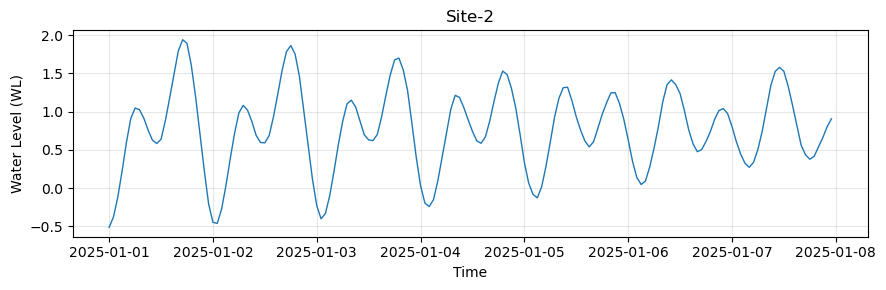

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9410170_met.csv"
time_col = "Time"
wl_col   = "WL"
# -------------------------------------------

# Read CSV
df = pd.read_csv(csv_path)

# Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col] = pd.to_numeric(df[wl_col], errors="coerce")

# Drop bad rows and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# Select first 7 days
t0 = df[time_col].iloc[0]
t_end = t0 + pd.Timedelta(days=7)
df_7d = df[(df[time_col] >= t0) & (df[time_col] < t_end)]

# Plot
plt.figure(figsize=(9, 3))
plt.plot(df_7d[time_col], df_7d[wl_col], linewidth=1)
plt.xlabel("Time")
plt.ylabel("Water Level (WL)")
plt.title("Site-2")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


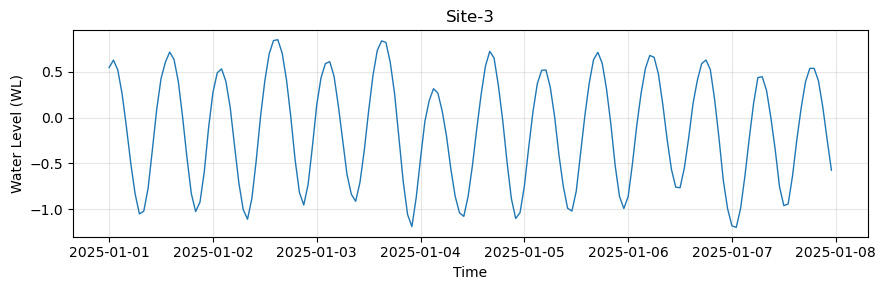

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8665530_met.csv"
time_col = "Time"
wl_col   = "WL"
# -------------------------------------------

# Read CSV
df = pd.read_csv(csv_path)

# Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col] = pd.to_numeric(df[wl_col], errors="coerce")

# Drop bad rows and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# Select first 7 days
t0 = df[time_col].iloc[0]
t_end = t0 + pd.Timedelta(days=7)
df_7d = df[(df[time_col] >= t0) & (df[time_col] < t_end)]

# Plot
plt.figure(figsize=(9, 3))
plt.plot(df_7d[time_col], df_7d[wl_col], linewidth=1)
plt.xlabel("Time")
plt.ylabel("Water Level (WL)")
plt.title("Site-3")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


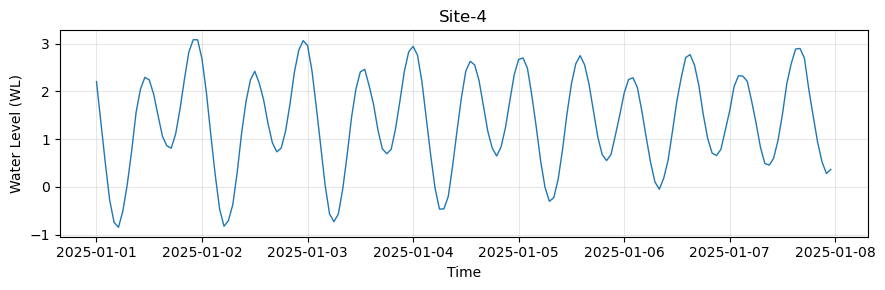

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9453220_met.csv"
time_col = "Time"
wl_col   = "WL"
# -------------------------------------------

# Read CSV
df = pd.read_csv(csv_path)

# Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col] = pd.to_numeric(df[wl_col], errors="coerce")

# Drop bad rows and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# Select first 7 days
t0 = df[time_col].iloc[0]
t_end = t0 + pd.Timedelta(days=7)
df_7d = df[(df[time_col] >= t0) & (df[time_col] < t_end)]

# Plot
plt.figure(figsize=(9, 3))
plt.plot(df_7d[time_col], df_7d[wl_col], linewidth=1)
plt.xlabel("Time")
plt.ylabel("Water Level (WL)")
plt.title("Site-4")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [12]:
import pandas as pd
import numpy as np

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8665530_met.csv"
time_col = "Time"
wl_col   = "WL"   # referenced to NAVD88
# -------------------------------------------

# 1. Read data
df = pd.read_csv(csv_path)

# 2. Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")

# 3. Clean and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col).reset_index(drop=True)

# 4. Restrict to year 2025 (safety check)
df = df[df[time_col].dt.year == 2025]

# 5. Compute Mean Sea Level (MSL) from time series
MSL = df[wl_col].mean()

# 6. Identify inundation (WL > MSL)
df["inundated"] = df[wl_col] > MSL

# 7. Compute time step in hours
# (assumes uniform spacing, typical for NOAA predictions)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 8. Total inundation hours
hours_inundated = df["inundated"].sum() * dt_hours

# 9. Output
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Time step: {dt_hours:.3f} hours")
print(f"Total marsh inundation time in 2025: {hours_inundated:.1f} hours")

# Optional: percentage of year inundated
hours_year = 365 * 24
percent = 100 * hours_inundated / hours_year
print(f"Percentage of year inundated: {percent:.1f}%")


Mean Sea Level (MSL): 0.053 m (NAVD88)
Time step: 1.000 hours
Total marsh inundation time in 2025: 4538.0 hours
Percentage of year inundated: 51.8%


In [13]:
import pandas as pd
import numpy as np

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8735180_met.csv"
time_col = "Time"
wl_col   = "WL"   # referenced to NAVD88
# -------------------------------------------

# 1. Read data
df = pd.read_csv(csv_path)

# 2. Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")

# 3. Clean and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col).reset_index(drop=True)

# 4. Restrict to year 2025 (safety check)
df = df[df[time_col].dt.year == 2025]

# 5. Compute Mean Sea Level (MSL) from time series
MSL = df[wl_col].mean()

# 6. Identify inundation (WL > MSL)
df["inundated"] = df[wl_col] > MSL

# 7. Compute time step in hours
# (assumes uniform spacing, typical for NOAA predictions)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 8. Total inundation hours
hours_inundated = df["inundated"].sum() * dt_hours

# 9. Output
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Time step: {dt_hours:.3f} hours")
print(f"Total marsh inundation time in 2025: {hours_inundated:.1f} hours")

# Optional: percentage of year inundated
hours_year = 365 * 24
percent = 100 * hours_inundated / hours_year
print(f"Percentage of year inundated: {percent:.1f}%")


Mean Sea Level (MSL): 0.145 m (NAVD88)
Time step: 1.000 hours
Total marsh inundation time in 2025: 4406.0 hours
Percentage of year inundated: 50.3%


In [14]:
import pandas as pd
import numpy as np

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9410170_met.csv"
time_col = "Time"
wl_col   = "WL"   # referenced to NAVD88
# -------------------------------------------

# 1. Read data
df = pd.read_csv(csv_path)

# 2. Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")

# 3. Clean and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col).reset_index(drop=True)

# 4. Restrict to year 2025 (safety check)
df = df[df[time_col].dt.year == 2025]

# 5. Compute Mean Sea Level (MSL) from time series
MSL = df[wl_col].mean()

# 6. Identify inundation (WL > MSL)
df["inundated"] = df[wl_col] > MSL

# 7. Compute time step in hours
# (assumes uniform spacing, typical for NOAA predictions)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 8. Total inundation hours
hours_inundated = df["inundated"].sum() * dt_hours

# 9. Output
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Time step: {dt_hours:.3f} hours")
print(f"Total marsh inundation time in 2025: {hours_inundated:.1f} hours")

# Optional: percentage of year inundated
hours_year = 365 * 24
percent = 100 * hours_inundated / hours_year
print(f"Percentage of year inundated: {percent:.1f}%")


Mean Sea Level (MSL): 0.834 m (NAVD88)
Time step: 1.000 hours
Total marsh inundation time in 2025: 4521.0 hours
Percentage of year inundated: 51.6%


In [15]:
import pandas as pd
import numpy as np

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9453220_met.csv"
time_col = "Time"
wl_col   = "WL"   # referenced to NAVD88
# -------------------------------------------

# 1. Read data
df = pd.read_csv(csv_path)

# 2. Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")

# 3. Clean and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col).reset_index(drop=True)

# 4. Restrict to year 2025 (safety check)
df = df[df[time_col].dt.year == 2025]

# 5. Compute Mean Sea Level (MSL) from time series
MSL = df[wl_col].mean()

# 6. Identify inundation (WL > MSL)
df["inundated"] = df[wl_col] > MSL

# 7. Compute time step in hours
# (assumes uniform spacing, typical for NOAA predictions)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 8. Total inundation hours
hours_inundated = df["inundated"].sum() * dt_hours

# 9. Output
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Time step: {dt_hours:.3f} hours")
print(f"Total marsh inundation time in 2025: {hours_inundated:.1f} hours")

# Optional: percentage of year inundated
hours_year = 365 * 24
percent = 100 * hours_inundated / hours_year
print(f"Percentage of year inundated: {percent:.1f}%")


Mean Sea Level (MSL): 1.280 m (NAVD88)
Time step: 1.000 hours
Total marsh inundation time in 2025: 4546.0 hours
Percentage of year inundated: 51.9%


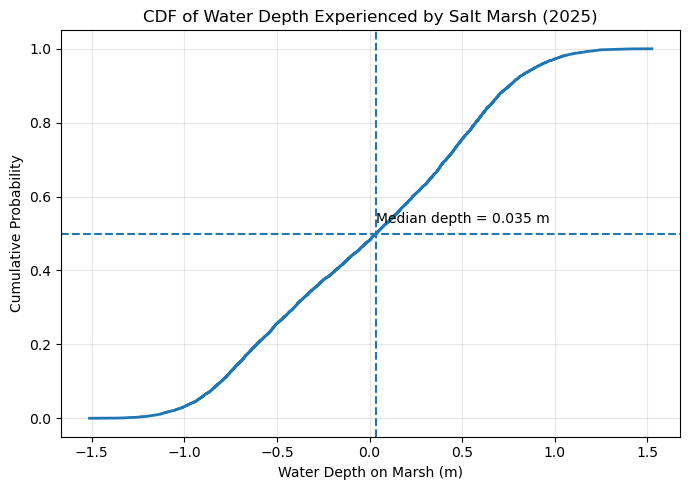

Mean Sea Level (MSL): 0.053 m (NAVD88)
Median water depth on marsh: 0.035 m


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8665530_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025]

# 3. Compute Mean Sea Level (MSL)
MSL = df[wl_col].mean()

# 4. Water depth on marsh
depth = df[wl_col] - MSL

# 5. Sort depths for CDF
depth_sorted = np.sort(depth.values)
cdf = np.arange(1, len(depth_sorted) + 1) / len(depth_sorted)

# 6. Median water depth
median_depth = np.median(depth_sorted)

# 7. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(depth_sorted, cdf, linewidth=2)
plt.axvline(median_depth, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Water Depth on Marsh (m)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Water Depth Experienced by Salt Marsh (2025)")
plt.grid(True, alpha=0.3)

plt.text(
    median_depth, 0.52,
    f"Median depth = {median_depth:.3f} m",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 8. Print result
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Median water depth on marsh: {median_depth:.3f} m")


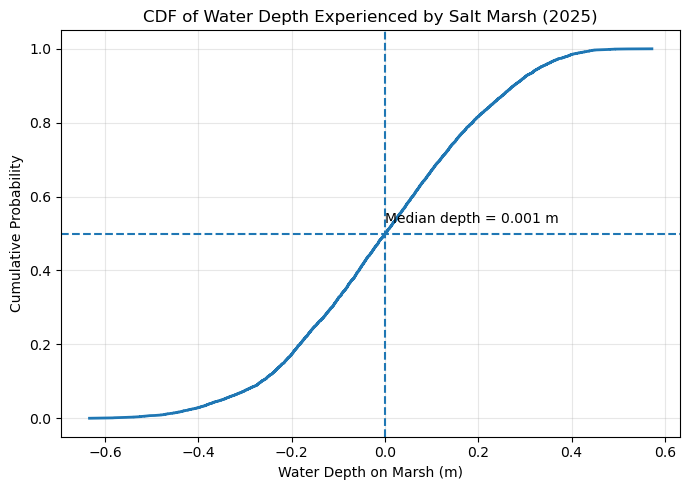

Mean Sea Level (MSL): 0.145 m (NAVD88)
Median water depth on marsh: 0.001 m


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8735180_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025]

# 3. Compute Mean Sea Level (MSL)
MSL = df[wl_col].mean()

# 4. Water depth on marsh
depth = df[wl_col] - MSL

# 5. Sort depths for CDF
depth_sorted = np.sort(depth.values)
cdf = np.arange(1, len(depth_sorted) + 1) / len(depth_sorted)

# 6. Median water depth
median_depth = np.median(depth_sorted)

# 7. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(depth_sorted, cdf, linewidth=2)
plt.axvline(median_depth, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Water Depth on Marsh (m)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Water Depth Experienced by Salt Marsh (2025)")
plt.grid(True, alpha=0.3)

plt.text(
    median_depth, 0.52,
    f"Median depth = {median_depth:.3f} m",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 8. Print result
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Median water depth on marsh: {median_depth:.3f} m")


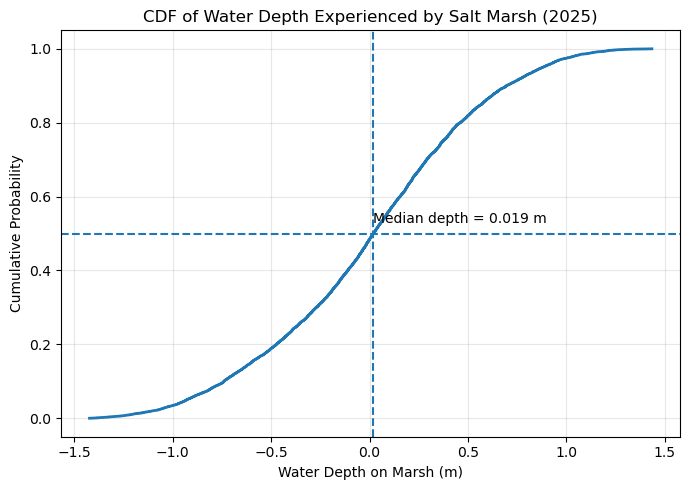

Mean Sea Level (MSL): 0.834 m (NAVD88)
Median water depth on marsh: 0.019 m


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9410170_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025]

# 3. Compute Mean Sea Level (MSL)
MSL = df[wl_col].mean()

# 4. Water depth on marsh
depth = df[wl_col] - MSL

# 5. Sort depths for CDF
depth_sorted = np.sort(depth.values)
cdf = np.arange(1, len(depth_sorted) + 1) / len(depth_sorted)

# 6. Median water depth
median_depth = np.median(depth_sorted)

# 7. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(depth_sorted, cdf, linewidth=2)
plt.axvline(median_depth, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Water Depth on Marsh (m)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Water Depth Experienced by Salt Marsh (2025)")
plt.grid(True, alpha=0.3)

plt.text(
    median_depth, 0.52,
    f"Median depth = {median_depth:.3f} m",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 8. Print result
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Median water depth on marsh: {median_depth:.3f} m")


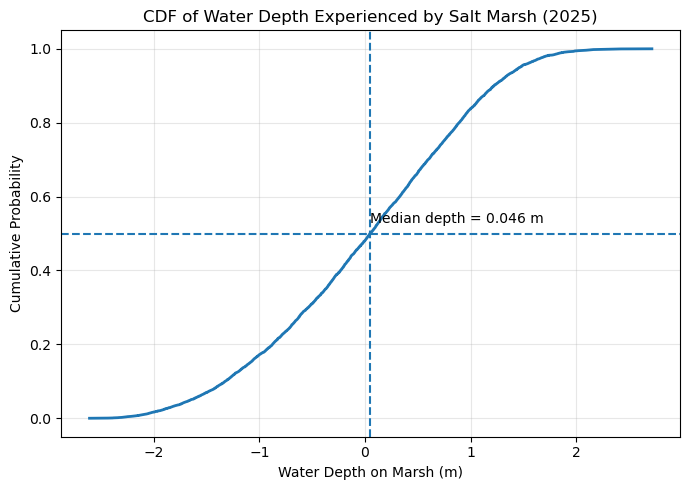

Mean Sea Level (MSL): 1.280 m (NAVD88)
Median water depth on marsh: 0.046 m


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9453220_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025]

# 3. Compute Mean Sea Level (MSL)
MSL = df[wl_col].mean()

# 4. Water depth on marsh
depth = df[wl_col] - MSL

# 5. Sort depths for CDF
depth_sorted = np.sort(depth.values)
cdf = np.arange(1, len(depth_sorted) + 1) / len(depth_sorted)

# 6. Median water depth
median_depth = np.median(depth_sorted)

# 7. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(depth_sorted, cdf, linewidth=2)
plt.axvline(median_depth, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Water Depth on Marsh (m)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Water Depth Experienced by Salt Marsh (2025)")
plt.grid(True, alpha=0.3)

plt.text(
    median_depth, 0.52,
    f"Median depth = {median_depth:.3f} m",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 8. Print result
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Median water depth on marsh: {median_depth:.3f} m")


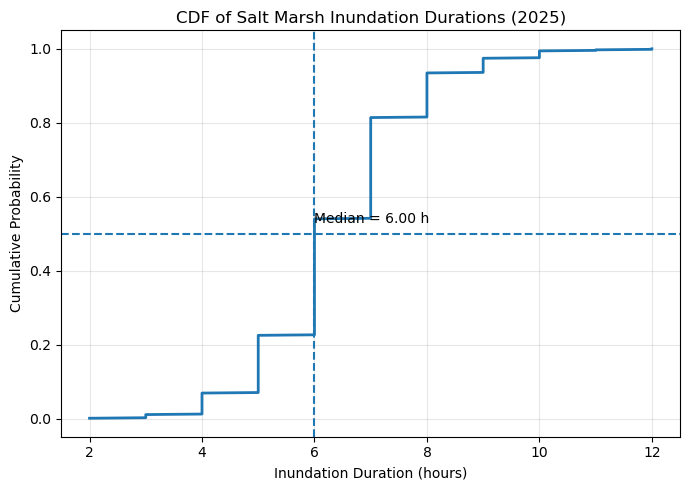

Mean Sea Level (MSL): 0.053 m (NAVD88)
Number of inundation events: 705
Median inundation duration: 6.00 hours


In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8665530_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025].reset_index(drop=True)

# 3. Compute Mean Sea Level (MSL)
MSL = df[wl_col].mean()

# 4. Inundation flag
df["inundated"] = df[wl_col] > MSL

# 5. Time step (hours)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 6. Identify continuous inundation events
# Create an event ID that increments when inundation starts
df["event_id"] = (df["inundated"] & ~df["inundated"].shift(fill_value=False)).cumsum()

# Keep only inundated points
events = df[df["inundated"]].groupby("event_id")

# 7. Compute duration of each inundation event (hours)
durations = events.size() * dt_hours
durations = durations.values  # numpy array

# 8. Sort durations and compute CDF
dur_sorted = np.sort(durations)
cdf = np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)

# 9. Median inundation duration
median_duration = np.median(dur_sorted)

# 10. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(dur_sorted, cdf, linewidth=2)
plt.axvline(median_duration, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Inundation Duration (hours)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Salt Marsh Inundation Durations (2025)")
plt.grid(True, alpha=0.3)

plt.text(
    median_duration, 0.52,
    f"Median = {median_duration:.2f} h",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 11. Print results
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Number of inundation events: {len(dur_sorted)}")
print(f"Median inundation duration: {median_duration:.2f} hours")


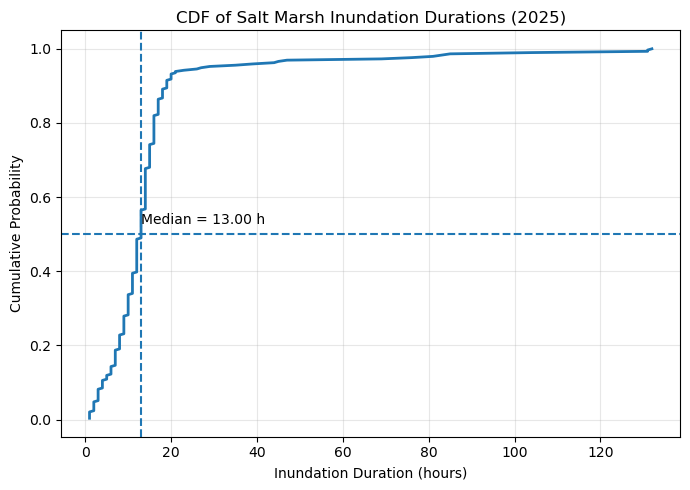

Mean Sea Level (MSL): 0.145 m (NAVD88)
Number of inundation events: 294
Median inundation duration: 13.00 hours


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8735180_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025].reset_index(drop=True)

# 3. Compute Mean Sea Level (MSL)
MSL = df[wl_col].mean()

# 4. Inundation flag
df["inundated"] = df[wl_col] > MSL

# 5. Time step (hours)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 6. Identify continuous inundation events
# Create an event ID that increments when inundation starts
df["event_id"] = (df["inundated"] & ~df["inundated"].shift(fill_value=False)).cumsum()

# Keep only inundated points
events = df[df["inundated"]].groupby("event_id")

# 7. Compute duration of each inundation event (hours)
durations = events.size() * dt_hours
durations = durations.values  # numpy array

# 8. Sort durations and compute CDF
dur_sorted = np.sort(durations)
cdf = np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)

# 9. Median inundation duration
median_duration = np.median(dur_sorted)

# 10. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(dur_sorted, cdf, linewidth=2)
plt.axvline(median_duration, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Inundation Duration (hours)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Salt Marsh Inundation Durations (2025)")
plt.grid(True, alpha=0.3)

plt.text(
    median_duration, 0.52,
    f"Median = {median_duration:.2f} h",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 11. Print results
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Number of inundation events: {len(dur_sorted)}")
print(f"Median inundation duration: {median_duration:.2f} hours")


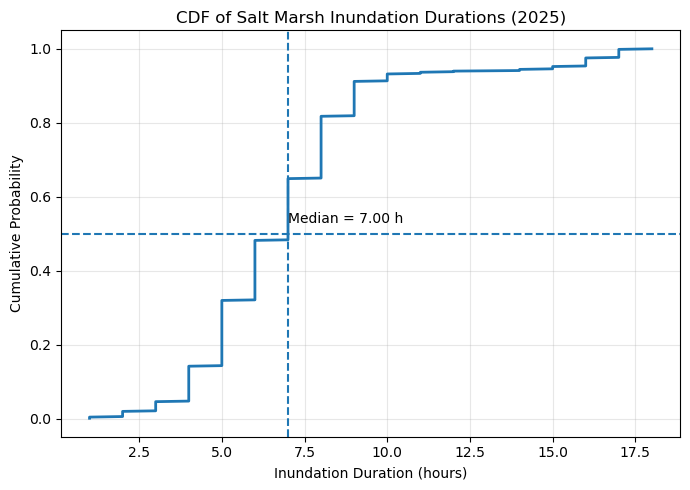

Mean Sea Level (MSL): 0.834 m (NAVD88)
Number of inundation events: 647
Median inundation duration: 7.00 hours


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9410170_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025].reset_index(drop=True)

# 3. Compute Mean Sea Level (MSL)
MSL = df[wl_col].mean()

# 4. Inundation flag
df["inundated"] = df[wl_col] > MSL

# 5. Time step (hours)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 6. Identify continuous inundation events
# Create an event ID that increments when inundation starts
df["event_id"] = (df["inundated"] & ~df["inundated"].shift(fill_value=False)).cumsum()

# Keep only inundated points
events = df[df["inundated"]].groupby("event_id")

# 7. Compute duration of each inundation event (hours)
durations = events.size() * dt_hours
durations = durations.values  # numpy array

# 8. Sort durations and compute CDF
dur_sorted = np.sort(durations)
cdf = np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)

# 9. Median inundation duration
median_duration = np.median(dur_sorted)

# 10. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(dur_sorted, cdf, linewidth=2)
plt.axvline(median_duration, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Inundation Duration (hours)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Salt Marsh Inundation Durations (2025)")
plt.grid(True, alpha=0.3)

plt.text(
    median_duration, 0.52,
    f"Median = {median_duration:.2f} h",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 11. Print results
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Number of inundation events: {len(dur_sorted)}")
print(f"Median inundation duration: {median_duration:.2f} hours")


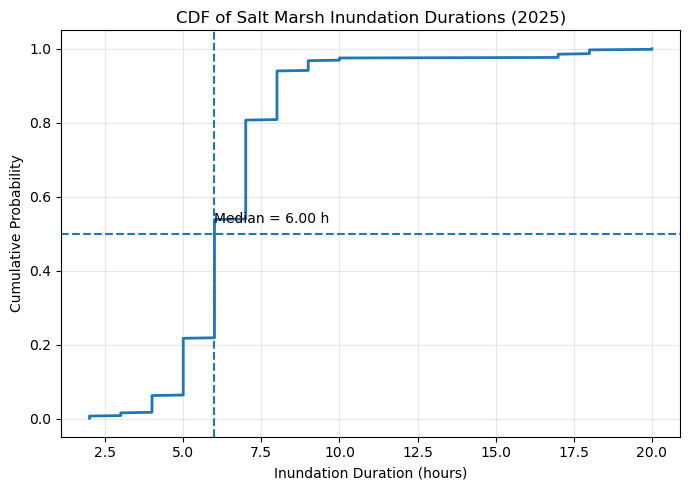

Mean Sea Level (MSL): 1.280 m (NAVD88)
Number of inundation events: 685
Median inundation duration: 6.00 hours


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9453220_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025].reset_index(drop=True)

# 3. Compute Mean Sea Level (MSL)
MSL = df[wl_col].mean()

# 4. Inundation flag
df["inundated"] = df[wl_col] > MSL

# 5. Time step (hours)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 6. Identify continuous inundation events
# Create an event ID that increments when inundation starts
df["event_id"] = (df["inundated"] & ~df["inundated"].shift(fill_value=False)).cumsum()

# Keep only inundated points
events = df[df["inundated"]].groupby("event_id")

# 7. Compute duration of each inundation event (hours)
durations = events.size() * dt_hours
durations = durations.values  # numpy array

# 8. Sort durations and compute CDF
dur_sorted = np.sort(durations)
cdf = np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)

# 9. Median inundation duration
median_duration = np.median(dur_sorted)

# 10. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(dur_sorted, cdf, linewidth=2)
plt.axvline(median_duration, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Inundation Duration (hours)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Salt Marsh Inundation Durations (2025)")
plt.grid(True, alpha=0.3)

plt.text(
    median_duration, 0.52,
    f"Median = {median_duration:.2f} h",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 11. Print results
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Number of inundation events: {len(dur_sorted)}")
print(f"Median inundation duration: {median_duration:.2f} hours")


In [24]:
import pandas as pd
import numpy as np

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8665530_met.csv"
time_col = "Time"
wl_col   = "WL"   # referenced to NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read data
df = pd.read_csv(csv_path)

# 2. Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")

# 3. Clean and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col).reset_index(drop=True)

# 4. Restrict to year 2025
df = df[df[time_col].dt.year == 2025]

# 5. Compute Mean Sea Level (MSL) from original time series
MSL = df[wl_col].mean()

# 6. Apply sea level rise
df["WL_SLR"] = df[wl_col] + SLR

# 7. Identify inundation under SLR
df["inundated_SLR"] = df["WL_SLR"] > MSL

# 8. Compute time step in hours
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 9. Total inundation hours with SLR
hours_inundated_SLR = df["inundated_SLR"].sum() * dt_hours

# 10. Output
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Time step: {dt_hours:.3f} hours")
print(f"Total marsh inundation time in 2025 (with SLR): {hours_inundated_SLR:.1f} hours")

# Optional: percentage of year inundated
hours_year = 365 * 24
percent = 100 * hours_inundated_SLR / hours_year
print(f"Percentage of year inundated (with SLR): {percent:.1f}%")


Mean Sea Level (MSL): 0.053 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Time step: 1.000 hours
Total marsh inundation time in 2025 (with SLR): 5680.0 hours
Percentage of year inundated (with SLR): 64.8%


In [25]:
import pandas as pd
import numpy as np

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8735180_met.csv"
time_col = "Time"
wl_col   = "WL"   # referenced to NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read data
df = pd.read_csv(csv_path)

# 2. Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")

# 3. Clean and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col).reset_index(drop=True)

# 4. Restrict to year 2025
df = df[df[time_col].dt.year == 2025]

# 5. Compute Mean Sea Level (MSL) from original time series
MSL = df[wl_col].mean()

# 6. Apply sea level rise
df["WL_SLR"] = df[wl_col] + SLR

# 7. Identify inundation under SLR
df["inundated_SLR"] = df["WL_SLR"] > MSL

# 8. Compute time step in hours
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 9. Total inundation hours with SLR
hours_inundated_SLR = df["inundated_SLR"].sum() * dt_hours

# 10. Output
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Time step: {dt_hours:.3f} hours")
print(f"Total marsh inundation time in 2025 (with SLR): {hours_inundated_SLR:.1f} hours")

# Optional: percentage of year inundated
hours_year = 365 * 24
percent = 100 * hours_inundated_SLR / hours_year
print(f"Percentage of year inundated (with SLR): {percent:.1f}%")


Mean Sea Level (MSL): 0.145 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Time step: 1.000 hours
Total marsh inundation time in 2025 (with SLR): 8109.0 hours
Percentage of year inundated (with SLR): 92.6%


In [26]:
import pandas as pd
import numpy as np

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9410170_met.csv"
time_col = "Time"
wl_col   = "WL"   # referenced to NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read data
df = pd.read_csv(csv_path)

# 2. Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")

# 3. Clean and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col).reset_index(drop=True)

# 4. Restrict to year 2025
df = df[df[time_col].dt.year == 2025]

# 5. Compute Mean Sea Level (MSL) from original time series
MSL = df[wl_col].mean()

# 6. Apply sea level rise
df["WL_SLR"] = df[wl_col] + SLR

# 7. Identify inundation under SLR
df["inundated_SLR"] = df["WL_SLR"] > MSL

# 8. Compute time step in hours
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 9. Total inundation hours with SLR
hours_inundated_SLR = df["inundated_SLR"].sum() * dt_hours

# 10. Output
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Time step: {dt_hours:.3f} hours")
print(f"Total marsh inundation time in 2025 (with SLR): {hours_inundated_SLR:.1f} hours")

# Optional: percentage of year inundated
hours_year = 365 * 24
percent = 100 * hours_inundated_SLR / hours_year
print(f"Percentage of year inundated (with SLR): {percent:.1f}%")


Mean Sea Level (MSL): 0.834 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Time step: 1.000 hours
Total marsh inundation time in 2025 (with SLR): 6274.0 hours
Percentage of year inundated (with SLR): 71.6%


In [27]:
import pandas as pd
import numpy as np

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9453220_met.csv"
time_col = "Time"
wl_col   = "WL"   # referenced to NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read data
df = pd.read_csv(csv_path)

# 2. Parse time and WL
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")

# 3. Clean and sort
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col).reset_index(drop=True)

# 4. Restrict to year 2025
df = df[df[time_col].dt.year == 2025]

# 5. Compute Mean Sea Level (MSL) from original time series
MSL = df[wl_col].mean()

# 6. Apply sea level rise
df["WL_SLR"] = df[wl_col] + SLR

# 7. Identify inundation under SLR
df["inundated_SLR"] = df["WL_SLR"] > MSL

# 8. Compute time step in hours
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 9. Total inundation hours with SLR
hours_inundated_SLR = df["inundated_SLR"].sum() * dt_hours

# 10. Output
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Time step: {dt_hours:.3f} hours")
print(f"Total marsh inundation time in 2025 (with SLR): {hours_inundated_SLR:.1f} hours")

# Optional: percentage of year inundated
hours_year = 365 * 24
percent = 100 * hours_inundated_SLR / hours_year
print(f"Percentage of year inundated (with SLR): {percent:.1f}%")


Mean Sea Level (MSL): 1.280 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Time step: 1.000 hours
Total marsh inundation time in 2025 (with SLR): 5460.0 hours
Percentage of year inundated (with SLR): 62.3%


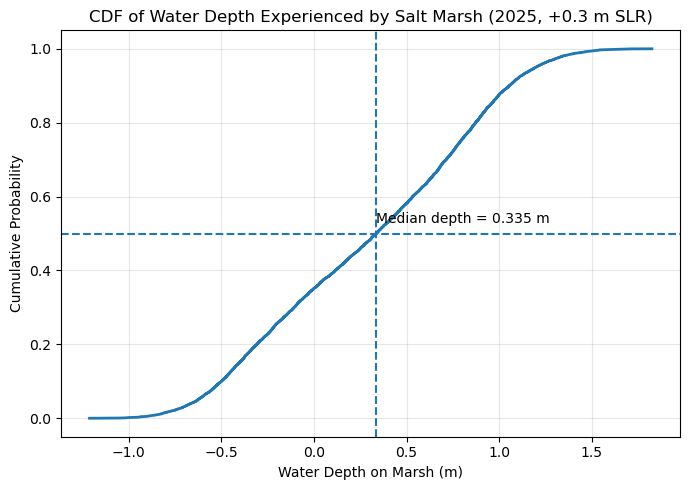

Mean Sea Level (MSL): 0.053 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Median water depth on marsh (with SLR): 0.335 m


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8665530_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025]

# 3. Compute Mean Sea Level (MSL) from original series
MSL = df[wl_col].mean()

# 4. Water depth on marsh WITH sea level rise
depth_slr = (df[wl_col] + SLR) - MSL

# 5. Sort depths for CDF
depth_sorted = np.sort(depth_slr.values)
cdf = np.arange(1, len(depth_sorted) + 1) / len(depth_sorted)

# 6. Median water depth
median_depth = np.median(depth_sorted)

# 7. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(depth_sorted, cdf, linewidth=2)
plt.axvline(median_depth, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Water Depth on Marsh (m)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Water Depth Experienced by Salt Marsh (2025, +0.3 m SLR)")
plt.grid(True, alpha=0.3)

plt.text(
    median_depth, 0.52,
    f"Median depth = {median_depth:.3f} m",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 8. Print result
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Median water depth on marsh (with SLR): {median_depth:.3f} m")


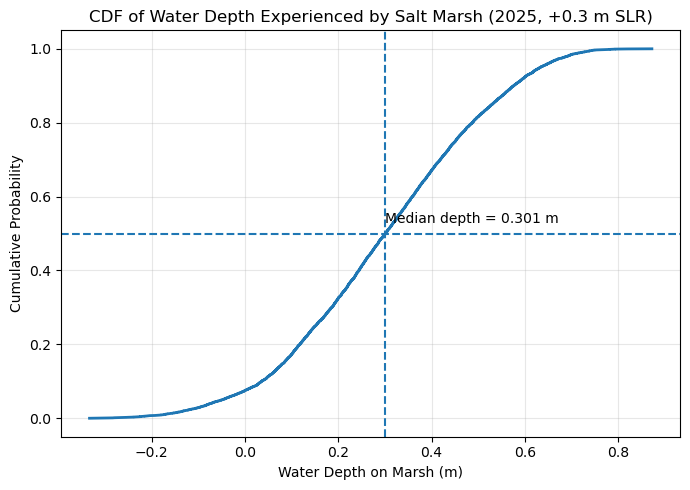

Mean Sea Level (MSL): 0.145 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Median water depth on marsh (with SLR): 0.301 m


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8735180_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025]

# 3. Compute Mean Sea Level (MSL) from original series
MSL = df[wl_col].mean()

# 4. Water depth on marsh WITH sea level rise
depth_slr = (df[wl_col] + SLR) - MSL

# 5. Sort depths for CDF
depth_sorted = np.sort(depth_slr.values)
cdf = np.arange(1, len(depth_sorted) + 1) / len(depth_sorted)

# 6. Median water depth
median_depth = np.median(depth_sorted)

# 7. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(depth_sorted, cdf, linewidth=2)
plt.axvline(median_depth, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Water Depth on Marsh (m)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Water Depth Experienced by Salt Marsh (2025, +0.3 m SLR)")
plt.grid(True, alpha=0.3)

plt.text(
    median_depth, 0.52,
    f"Median depth = {median_depth:.3f} m",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 8. Print result
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Median water depth on marsh (with SLR): {median_depth:.3f} m")


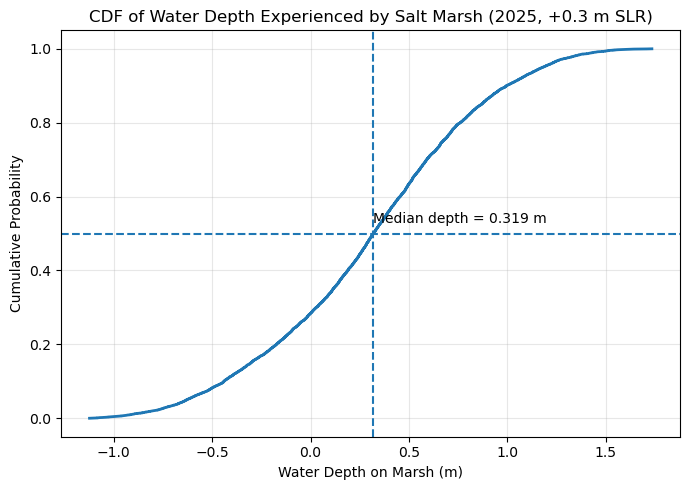

Mean Sea Level (MSL): 0.834 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Median water depth on marsh (with SLR): 0.319 m


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9410170_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025]

# 3. Compute Mean Sea Level (MSL) from original series
MSL = df[wl_col].mean()

# 4. Water depth on marsh WITH sea level rise
depth_slr = (df[wl_col] + SLR) - MSL

# 5. Sort depths for CDF
depth_sorted = np.sort(depth_slr.values)
cdf = np.arange(1, len(depth_sorted) + 1) / len(depth_sorted)

# 6. Median water depth
median_depth = np.median(depth_sorted)

# 7. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(depth_sorted, cdf, linewidth=2)
plt.axvline(median_depth, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Water Depth on Marsh (m)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Water Depth Experienced by Salt Marsh (2025, +0.3 m SLR)")
plt.grid(True, alpha=0.3)

plt.text(
    median_depth, 0.52,
    f"Median depth = {median_depth:.3f} m",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 8. Print result
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Median water depth on marsh (with SLR): {median_depth:.3f} m")


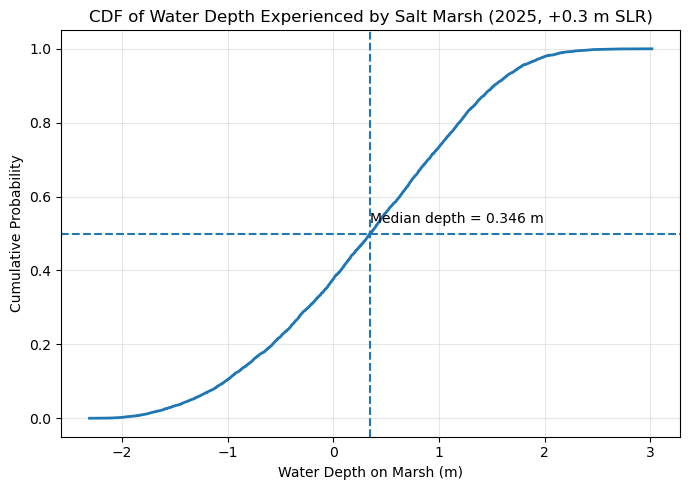

Mean Sea Level (MSL): 1.280 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Median water depth on marsh (with SLR): 0.346 m


In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9453220_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025]

# 3. Compute Mean Sea Level (MSL) from original series
MSL = df[wl_col].mean()

# 4. Water depth on marsh WITH sea level rise
depth_slr = (df[wl_col] + SLR) - MSL

# 5. Sort depths for CDF
depth_sorted = np.sort(depth_slr.values)
cdf = np.arange(1, len(depth_sorted) + 1) / len(depth_sorted)

# 6. Median water depth
median_depth = np.median(depth_sorted)

# 7. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(depth_sorted, cdf, linewidth=2)
plt.axvline(median_depth, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Water Depth on Marsh (m)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Water Depth Experienced by Salt Marsh (2025, +0.3 m SLR)")
plt.grid(True, alpha=0.3)

plt.text(
    median_depth, 0.52,
    f"Median depth = {median_depth:.3f} m",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 8. Print result
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Median water depth on marsh (with SLR): {median_depth:.3f} m")


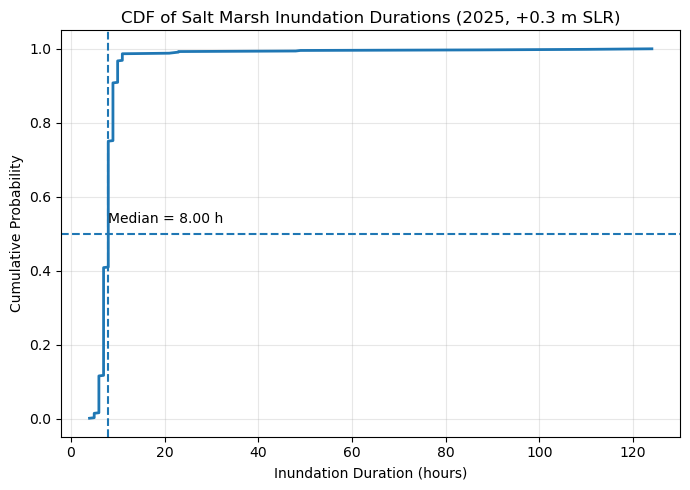

Mean Sea Level (MSL): 0.053 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Number of inundation events (with SLR): 673
Median inundation duration (with SLR): 8.00 hours


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8665530_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025].reset_index(drop=True)

# 3. Compute Mean Sea Level (MSL) from original series
MSL = df[wl_col].mean()

# 4. Apply sea level rise
df["WL_SLR"] = df[wl_col] + SLR

# 5. Inundation flag with SLR
df["inundated_SLR"] = df["WL_SLR"] > MSL

# 6. Time step (hours)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 7. Identify continuous inundation events (with SLR)
df["event_id"] = (
    df["inundated_SLR"] & ~df["inundated_SLR"].shift(fill_value=False)
).cumsum()

# Keep only inundated points
events = df[df["inundated_SLR"]].groupby("event_id")

# 8. Compute duration of each inundation event (hours)
durations = events.size() * dt_hours
durations = durations.values

# 9. Sort durations and compute CDF
dur_sorted = np.sort(durations)
cdf = np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)

# 10. Median inundation duration
median_duration = np.median(dur_sorted)

# 11. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(dur_sorted, cdf, linewidth=2)
plt.axvline(median_duration, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Inundation Duration (hours)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Salt Marsh Inundation Durations (2025, +0.3 m SLR)")
plt.grid(True, alpha=0.3)

plt.text(
    median_duration, 0.52,
    f"Median = {median_duration:.2f} h",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 12. Print results
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Number of inundation events (with SLR): {len(dur_sorted)}")
print(f"Median inundation duration (with SLR): {median_duration:.2f} hours")


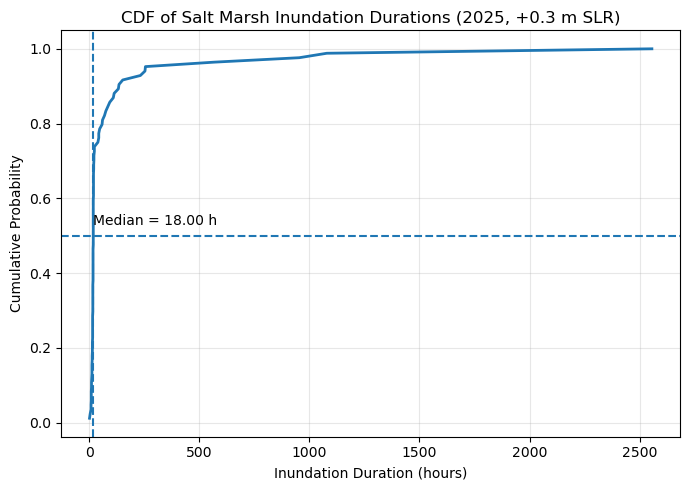

Mean Sea Level (MSL): 0.145 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Number of inundation events (with SLR): 84
Median inundation duration (with SLR): 18.00 hours


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_8735180_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025].reset_index(drop=True)

# 3. Compute Mean Sea Level (MSL) from original series
MSL = df[wl_col].mean()

# 4. Apply sea level rise
df["WL_SLR"] = df[wl_col] + SLR

# 5. Inundation flag with SLR
df["inundated_SLR"] = df["WL_SLR"] > MSL

# 6. Time step (hours)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 7. Identify continuous inundation events (with SLR)
df["event_id"] = (
    df["inundated_SLR"] & ~df["inundated_SLR"].shift(fill_value=False)
).cumsum()

# Keep only inundated points
events = df[df["inundated_SLR"]].groupby("event_id")

# 8. Compute duration of each inundation event (hours)
durations = events.size() * dt_hours
durations = durations.values

# 9. Sort durations and compute CDF
dur_sorted = np.sort(durations)
cdf = np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)

# 10. Median inundation duration
median_duration = np.median(dur_sorted)

# 11. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(dur_sorted, cdf, linewidth=2)
plt.axvline(median_duration, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Inundation Duration (hours)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Salt Marsh Inundation Durations (2025, +0.3 m SLR)")
plt.grid(True, alpha=0.3)

plt.text(
    median_duration, 0.52,
    f"Median = {median_duration:.2f} h",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 12. Print results
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Number of inundation events (with SLR): {len(dur_sorted)}")
print(f"Median inundation duration (with SLR): {median_duration:.2f} hours")


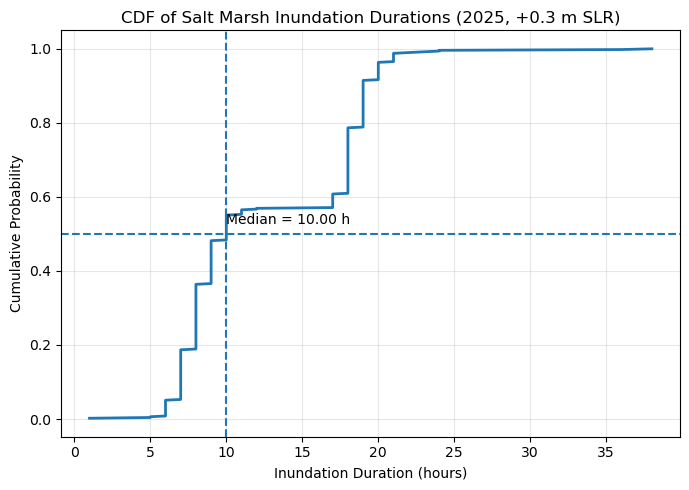

Mean Sea Level (MSL): 0.834 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Number of inundation events (with SLR): 492
Median inundation duration (with SLR): 10.00 hours


In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9410170_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025].reset_index(drop=True)

# 3. Compute Mean Sea Level (MSL) from original series
MSL = df[wl_col].mean()

# 4. Apply sea level rise
df["WL_SLR"] = df[wl_col] + SLR

# 5. Inundation flag with SLR
df["inundated_SLR"] = df["WL_SLR"] > MSL

# 6. Time step (hours)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 7. Identify continuous inundation events (with SLR)
df["event_id"] = (
    df["inundated_SLR"] & ~df["inundated_SLR"].shift(fill_value=False)
).cumsum()

# Keep only inundated points
events = df[df["inundated_SLR"]].groupby("event_id")

# 8. Compute duration of each inundation event (hours)
durations = events.size() * dt_hours
durations = durations.values

# 9. Sort durations and compute CDF
dur_sorted = np.sort(durations)
cdf = np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)

# 10. Median inundation duration
median_duration = np.median(dur_sorted)

# 11. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(dur_sorted, cdf, linewidth=2)
plt.axvline(median_duration, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Inundation Duration (hours)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Salt Marsh Inundation Durations (2025, +0.3 m SLR)")
plt.grid(True, alpha=0.3)

plt.text(
    median_duration, 0.52,
    f"Median = {median_duration:.2f} h",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 12. Print results
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Number of inundation events (with SLR): {len(dur_sorted)}")
print(f"Median inundation duration (with SLR): {median_duration:.2f} hours")


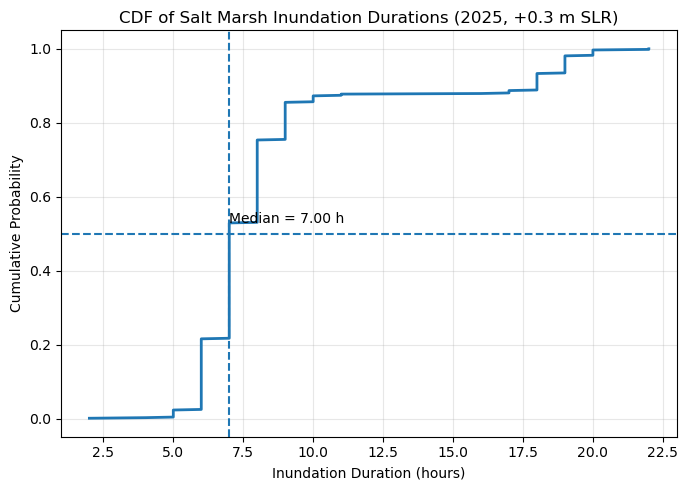

Mean Sea Level (MSL): 1.280 m (NAVD88)
Assumed Sea Level Rise: +0.30 m
Number of inundation events (with SLR): 629
Median inundation duration (with SLR): 7.00 hours


In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------- USER INPUT ----------------
csv_path = r"D:\Dipen Saha\Course Work\Spring 2026\Homework\Homework-1\CO-OPS_9453220_met.csv"
time_col = "Time"
wl_col   = "WL"   # NAVD88
SLR = 0.3         # meters
# -------------------------------------------

# 1. Read and clean data
df = pd.read_csv(csv_path)
df[time_col] = pd.to_datetime(df[time_col], errors="coerce")
df[wl_col]   = pd.to_numeric(df[wl_col], errors="coerce")
df = df.dropna(subset=[time_col, wl_col]).sort_values(time_col)

# 2. Restrict to 2025
df = df[df[time_col].dt.year == 2025].reset_index(drop=True)

# 3. Compute Mean Sea Level (MSL) from original series
MSL = df[wl_col].mean()

# 4. Apply sea level rise
df["WL_SLR"] = df[wl_col] + SLR

# 5. Inundation flag with SLR
df["inundated_SLR"] = df["WL_SLR"] > MSL

# 6. Time step (hours)
dt_hours = df[time_col].diff().dt.total_seconds().median() / 3600.0

# 7. Identify continuous inundation events (with SLR)
df["event_id"] = (
    df["inundated_SLR"] & ~df["inundated_SLR"].shift(fill_value=False)
).cumsum()

# Keep only inundated points
events = df[df["inundated_SLR"]].groupby("event_id")

# 8. Compute duration of each inundation event (hours)
durations = events.size() * dt_hours
durations = durations.values

# 9. Sort durations and compute CDF
dur_sorted = np.sort(durations)
cdf = np.arange(1, len(dur_sorted) + 1) / len(dur_sorted)

# 10. Median inundation duration
median_duration = np.median(dur_sorted)

# 11. Plot CDF
plt.figure(figsize=(7, 5))
plt.plot(dur_sorted, cdf, linewidth=2)
plt.axvline(median_duration, linestyle="--", linewidth=1.5)
plt.axhline(0.5, linestyle="--", linewidth=1.5)

plt.xlabel("Inundation Duration (hours)")
plt.ylabel("Cumulative Probability")
plt.title("CDF of Salt Marsh Inundation Durations (2025, +0.3 m SLR)")
plt.grid(True, alpha=0.3)

plt.text(
    median_duration, 0.52,
    f"Median = {median_duration:.2f} h",
    ha="left", va="bottom"
)

plt.tight_layout()
plt.show()

# 12. Print results
print(f"Mean Sea Level (MSL): {MSL:.3f} m (NAVD88)")
print(f"Assumed Sea Level Rise: +{SLR:.2f} m")
print(f"Number of inundation events (with SLR): {len(dur_sorted)}")
print(f"Median inundation duration (with SLR): {median_duration:.2f} hours")


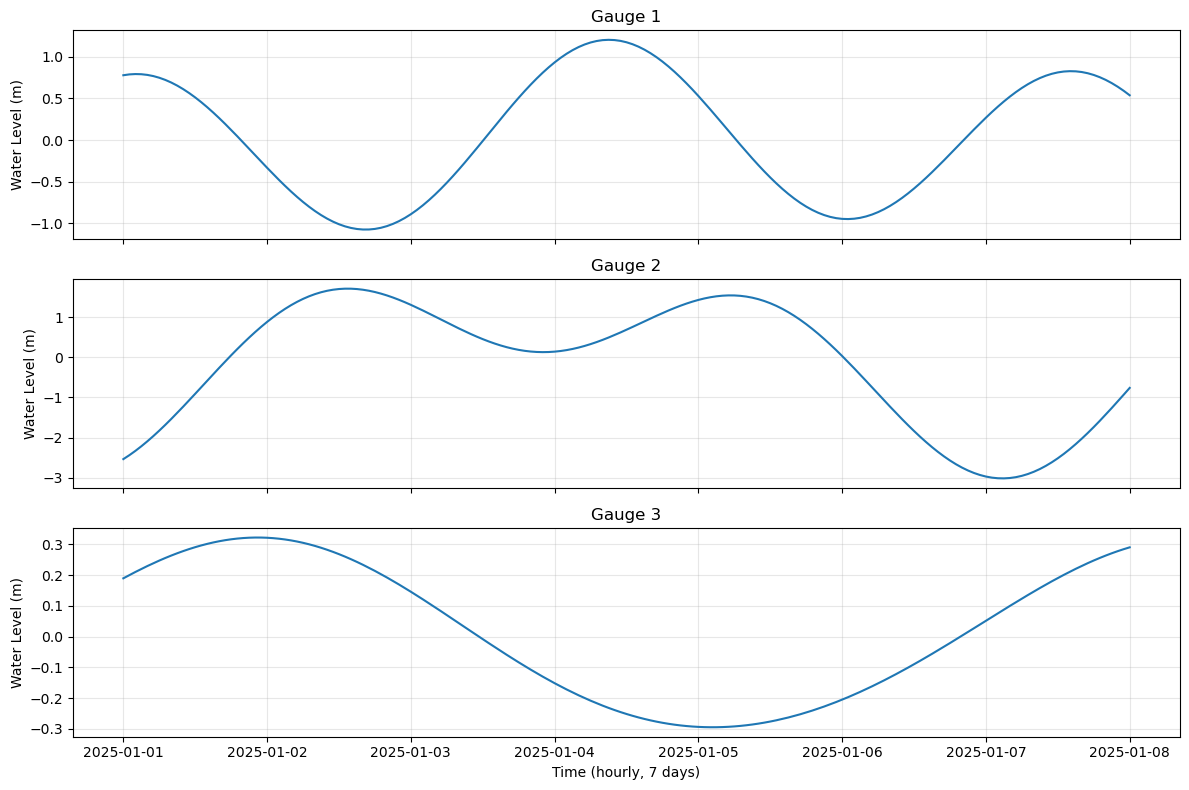

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ INPUT: harmonic constants ------------------
# omega in hr^-1, H in m, alpha in degrees
constituents = [
    ("M2", 0.0805),
    ("K1", 0.0418),
    ("O1", 0.0387),
    ("S2", 0.0833),
    ("N2", 0.0790),
    ("J1", 0.0433),
    ("Q1", 0.0372),
]

gauges = {
    "Gauge 1": {
        "M2": (0.7635, 9.2),
        "K1": (0.1085, 209.4),
        "O1": (0.0784, 203.6),
        "S2": (0.1177, 54.6),
        "N2": (0.1462, 355.7),
        "J1": (0.0094, 204.54),
        "Q1": (0.0139, 202.9),
    },
    "Gauge 2": {
        "M2": (1.0644, 138.2),
        "K1": (0.9957, 165.1),
        "O1": (0.4535, 144.9),
        "S2": (0.2360, 178.3),
        "N2": (0.1708, 111.6),
        "J1": (0.0618, 167.9),
        "Q1": (0.0558, 147.0),
    },
    "Gauge 3": {
        "M2": (0.0143, 126.8),
        "K1": (0.1528, 59.1),
        "O1": (0.1266, 40.9),
        "S2": (0.0019, 50.5),
        "N2": (0.0016, 131.1),
        "J1": (0.0087, 51.3),
        "Q1": (0.0217, 32.0),
    },
}
# ---------------------------------------------------------------

def predict_tide(gauge_dict, t_hours):
    """Return eta(t) from harmonic synthesis using eta = sum H cos(ω t - α)."""
    eta = np.zeros_like(t_hours, dtype=float)
    for name, omega in constituents:
        H, alpha_deg = gauge_dict[name]
        alpha_rad = np.deg2rad(alpha_deg)
        eta += H * np.cos(omega * t_hours - alpha_rad)
    return eta

# --------- time axis: hourly for 7 days ----------
n_days = 7
t_hours = np.arange(0, n_days * 24 + 1, 1)  # 0..168 hours
# optional: put a real datetime axis (edit start date if you want)
start = pd.Timestamp("2025-01-01 00:00")
time = start + pd.to_timedelta(t_hours, unit="h")
# ------------------------------------------------

# Predict for each gauge
pred = {}
for gname, gdict in gauges.items():
    pred[gname] = predict_tide(gdict, t_hours)

# ------------------ Plot ------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (gname, eta) in zip(axes, pred.items()):
    ax.plot(time, eta, linewidth=1.5)
    ax.set_title(gname)
    ax.set_ylabel("Water Level (m)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (hourly, 7 days)")
plt.tight_layout()
plt.show()


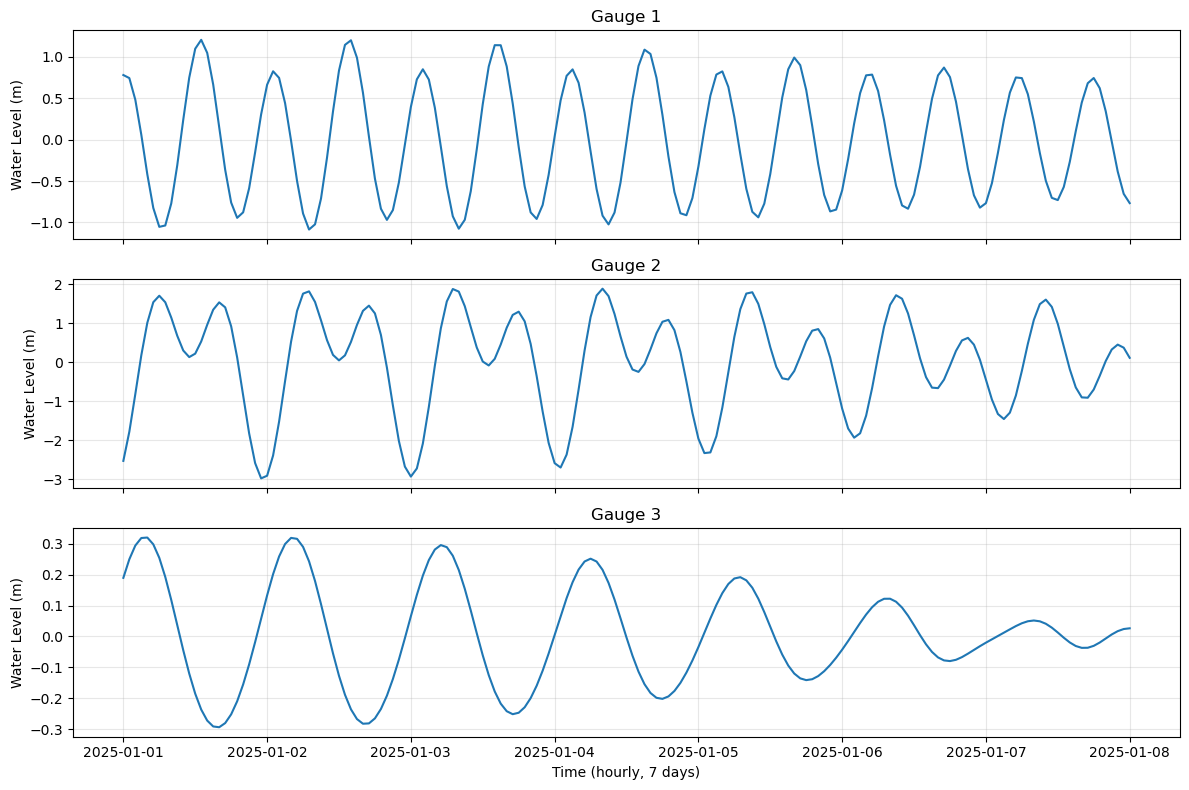

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------ INPUT: harmonic constants ------------------
# omega in hr^-1 (cycles per hour), H in m, alpha in degrees
constituents = [
    ("M2", 0.0805),
    ("K1", 0.0418),
    ("O1", 0.0387),
    ("S2", 0.0833),
    ("N2", 0.0790),
    ("J1", 0.0433),
    ("Q1", 0.0372),
]

gauges = {
    "Gauge 1": {
        "M2": (0.7635, 9.2),
        "K1": (0.1085, 209.4),
        "O1": (0.0784, 203.6),
        "S2": (0.1177, 54.6),
        "N2": (0.1462, 355.7),
        "J1": (0.0094, 204.54),
        "Q1": (0.0139, 202.9),
    },
    "Gauge 2": {
        "M2": (1.0644, 138.2),
        "K1": (0.9957, 165.1),
        "O1": (0.4535, 144.9),
        "S2": (0.2360, 178.3),
        "N2": (0.1708, 111.6),
        "J1": (0.0618, 167.9),
        "Q1": (0.0558, 147.0),
    },
    "Gauge 3": {
        "M2": (0.0143, 126.8),
        "K1": (0.1528, 59.1),
        "O1": (0.1266, 40.9),
        "S2": (0.0019, 50.5),
        "N2": (0.0016, 131.1),
        "J1": (0.0087, 51.3),
        "Q1": (0.0217, 32.0),
    },
}
# ---------------------------------------------------------------

def predict_tide(gauge_dict, t_hours):
    """
    Harmonic synthesis using angular frequency:
    eta(t) = sum H cos(2π ω t - α)
    """
    eta = np.zeros_like(t_hours, dtype=float)
    for name, omega in constituents:
        H, alpha_deg = gauge_dict[name]
        alpha_rad = np.deg2rad(alpha_deg)
        omega_ang = 2 * np.pi * omega   # <-- key modification
        eta += H * np.cos(omega_ang * t_hours - alpha_rad)
    return eta

# --------- time axis: hourly for 7 days ----------
n_days = 7
t_hours = np.arange(0, n_days * 24 + 1, 1)  # 0..168 hours

start = pd.Timestamp("2025-01-01 00:00")
time = start + pd.to_timedelta(t_hours, unit="h")
# ------------------------------------------------

# Predict for each gauge
pred = {}
for gname, gdict in gauges.items():
    pred[gname] = predict_tide(gdict, t_hours)

# ------------------ Plot ------------------
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for ax, (gname, eta) in zip(axes, pred.items()):
    ax.plot(time, eta, linewidth=1.5)
    ax.set_title(gname)
    ax.set_ylabel("Water Level (m)")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (hourly, 7 days)")
plt.tight_layout()
plt.show()
